# <span style="color:#0b486b">  Student Information</span>
***
Surname: **Goh**  <br/>
Firstname: **Jia Xuan**    <br/>
Student ID: **33589666**    <br/>
Email: **jgoh0043@student.monash.edu**    <br/>
Your tutorial time: **Thursday 2-4pm**    <br/>
***

## <span style="color:#0b486b">Part 1: Theory and Knowledge Questions</span>
<div style="text-align: right"><span style="color:red; font-weight:bold">[Total marks for this part: 30 points]<span></div>

The first part of this assignment is to demonstrate your knowledge in deep learning that you have acquired from the lectures and tutorials materials. Most of the contents in this assignment are drawn from **the lectures and tutorials from weeks 1 to 4**. Going through these materials before attempting this part is highly recommended.

####  <span style="color:red">**Question 1.1**</span> **Activation function plays an important role in modern Deep NNs. For each of the activation functions below, state its output range, find its derivative (show your steps), and plot the activation fuction and its derivative**

<span style="color:red">**(a)**</span> Exponential linear unit (ELU): $\text{ELU}(x)=\begin{cases}
0.1\left(\exp(x)-1\right) & \text{if}\,x\leq0\\
x & \text{if}\,x>0
\end{cases}$
<div style="text-align: right"><span style="color:red">[1.5 points]</span></div>

<span style="color:red">**(b)**</span> Gaussian Error Linear Unit (GELU): $\text{GELU}(x)=x\Phi(x)$ where $\Phi(x)$ is the `probability cummulative function` of the standard Gaussian distribution or $\Phi(x) = \mathbb{P}\left(X\leq x\right)$ where $X \sim N\left(0,1\right)$. In addition, the GELU activation fuction (the link for the [main paper](https://arxiv.org/pdf/1606.08415v5.pdf)) has been widely used in the state-of-the-art Vision for Transformers (e.g., here is the link for [the main ViT paper](https://arxiv.org/pdf/2010.11929v2.pdf)).
<div style="text-align: right"><span style="color:red">[1.5 points]</span></div>

(a) Output range:


- If $x < 0$:  
  $\operatorname{ELU}(x)=0.1(e^{x}-1)$.  
  As $x\to -\infty$, $e^{x}\to 0$, so $\operatorname{ELU}(x)\to 0.1(0-1)=-0.1.$  
  As $x \to 0^{-}$, $e^{x}\to 1^{-}$, so $\operatorname{ELU}(x)\to 0.1(1-1)=0.$  
  Hence for $x<0$, the output lies in $(-0.1,0).$

- If $x=0$:  
  $\operatorname{ELU}(0)=0.1(e^{0}-1)=0.$

- If $x>0$:  
  $\operatorname{ELU}(x)=x.$  
  As $x\to 0^{+}$, $\operatorname{ELU}(x)\to 0.$  
  As $x\to +\infty$, $\operatorname{ELU}(x)\to +\infty.$  
  So for $x>0$, the output lies in $(0,\infty).$

**Therefore, the overall output range is:**

$$
\operatorname{ELU}(x)\in(-0.1,\infty)
$$


Derivative:

- For $x<0$:
$$
\frac{d}{dx}\big[0.1(e^{x}-1)\big] = 0.1 e^{x}.
$$

- For $x>0$:
$$
\frac{d}{dx}[x] = 1.
$$

**Check continuity at $x=0$:**

Left-hand derivative at $x=0$:
$$
\left.\frac{d}{dx}\operatorname{ELU}(x)\right|_{0^-} = 0.1 e^{0} = 0.1.
$$

Right-hand derivative at $x=0$:
$$
\left.\frac{d}{dx}\operatorname{ELU}(x)\right|_{0^+} = 1.
$$

Since $0.1 \neq 1$, the left and right derivatives are different.

**Conclusion (final piecewise derivative):**
$$
\frac{d}{dx}\operatorname{ELU}(x)=
\begin{cases}
0.1 e^{x}, & x<0,\\[6pt]
\text{undefined}, & x=0,\\[6pt]
1, & x>0.
\end{cases}
$$

The derivative equals $0.1 e^{x}$ for $x<0$, equals $1$ for $x>0$, and is not defined at $x=0$ because the one-sided derivatives do not match.

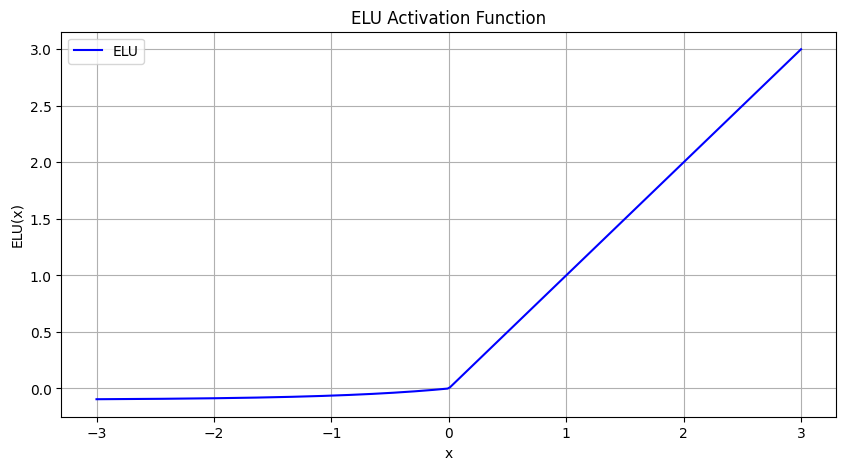

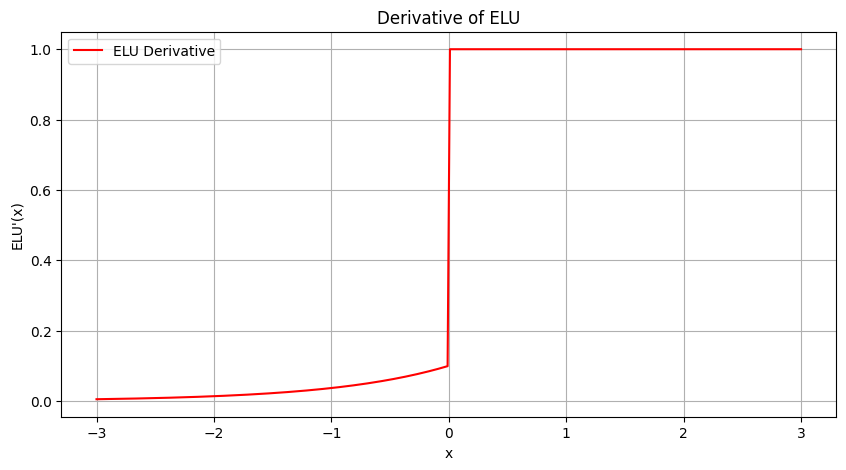

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def elu(x, alpha):
    if x <= 0:
        return alpha * (np.exp(x) - 1)
    else:
        return x

def elu_der(x, alpha):
    if x < 0:
        return alpha * np.exp(x)
    elif x > 0:
        return 1
    else:
        return np.nan

# Smaller x-range
x = np.linspace(-3, 3, 300)
alpha = 0.1

# ELU plot
plt.figure(figsize=(10, 5))
plt.plot(x, [elu(val, alpha) for val in x], label="ELU", color="blue")
plt.title("ELU Activation Function")
plt.xlabel("x")
plt.ylabel("ELU(x)")
plt.grid(True)
plt.legend()
plt.show()

# Derivative plot
plt.figure(figsize=(10, 5))
plt.plot(x, [elu_der(val, alpha) for val in x], label="ELU Derivative", color="red")
plt.title("Derivative of ELU")
plt.xlabel("x")
plt.ylabel("ELU'(x)")
plt.grid(True)
plt.legend()
plt.show()


(a) **Output range:**
- If $x<0$:  
  $\operatorname{GELU}(x)=x\Phi(x)$. Since $x<0$ and $\Phi(x)\in(0,0.5)$, the product is negative and tends to $0^-$ as $x\to0^-$ and as $x\to-\infty$. The function has a finite negative minimum $m$ at some $x<0$ (numerically $m\approx -0.1699712$ at $x\approx -0.7517915$), so the values for $x<0$ cover $(m,0)$.

- If $x=0$:  
  $\operatorname{GELU}(0)=0\cdot\Phi(0)=0.$

- If $x>0$:  
  $\operatorname{GELU}(x)=x\Phi(x)>0$ and as $x\to\infty$ this tends to $+\infty$.

Therefore the overall output range is
$$
\operatorname{GELU}(x)\in [m,\infty)\quad\text{where }m=\min_{x\in\mathbb{R}}x\Phi(x)\approx -0.1699712 \approx -0.17.
$$

**Derivative:**

From the product rule:
$$
\frac{d}{dx}\operatorname{GELU}(x) = \Phi(x) + x\phi(x),
$$
where $\Phi(x)$ is the standard normal CDF and $\phi(x)$ is the standard normal PDF.


- **As $x \to -\infty$:**  
  $\Phi(x) \to 0$, and $x\phi(x)\to 0$.  
  Therefore,
  $$
  \lim_{x\to -\infty}\frac{d}{dx}\operatorname{GELU}(x) = 0.
  $$

- **At $x = 0$:**  
  $\Phi(0) = \tfrac{1}{2},\quad \phi(0)=\tfrac{1}{\sqrt{2\pi}}.$  
  Hence,
  $$
  \frac{d}{dx}\operatorname{GELU}(0) = \tfrac{1}{2}.
  $$

- **As $x \to +\infty$:**  
  $\Phi(x)\to 1,\quad x\phi(x)\to 0.$  
  Therefore,
  $$
  \lim_{x\to +\infty}\frac{d}{dx}\operatorname{GELU}(x) = 1.
  $$

Therefore,

$$
\frac{d}{dx}\operatorname{GELU}(x) =
\begin{cases}
0 & \text{as } x \to -\infty, \\\\[6pt]
\dfrac{1}{2} & \text{at } x=0, \\\\[10pt]
1 & \text{as } x \to +\infty.
\end{cases}
$$

And in general for finite $x$:
$$
\frac{d}{dx}\operatorname{GELU}(x) = \Phi(x) + x\phi(x).
$$


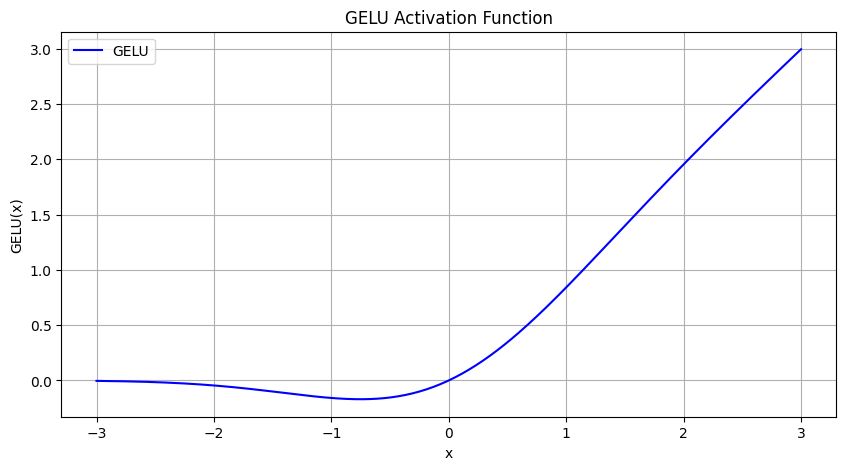

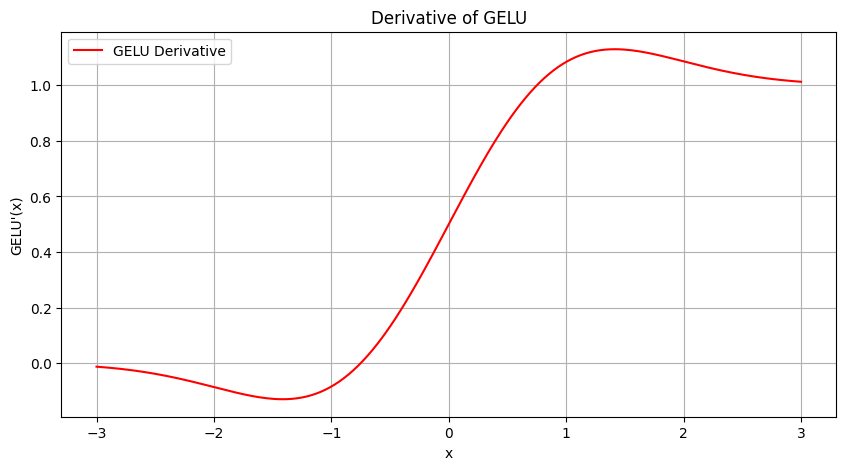

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def gelu(x):
    cdf = 0.5 * (1.0 + torch.erf(x / np.sqrt(2.0)))
    return x * cdf

def gelu_der(x):
    cdf = 0.5 * (1.0 + torch.erf(x / np.sqrt(2.0)))
    pdf = (1.0 / np.sqrt(2.0 * np.pi)) * torch.exp(-0.5 * x ** 2)
    return cdf + x * pdf

# Smaller x range for better visibility
x = torch.linspace(-3, 3, 300)

# Plot GELU
plt.figure(figsize=(10, 5))
plt.plot(x.numpy(), gelu(x).numpy(), label="GELU", color="blue")
plt.title("GELU Activation Function")
plt.xlabel("x")
plt.ylabel("GELU(x)")
plt.grid(True)
plt.legend()
plt.show()

# Plot derivative
plt.figure(figsize=(10, 5))
plt.plot(x.numpy(), gelu_der(x).numpy(), label="GELU Derivative", color="red")
plt.title("Derivative of GELU")
plt.xlabel("x")
plt.ylabel("GELU'(x)")
plt.grid(True)
plt.legend()
plt.show()


####  <span style="color:red">**Question 1.2:**</span> **Assume that we feed a data point $x$ with a ground-truth label $y=2$ to the feed-forward neural network with the `ReLU activation` function as shown in the following figure**


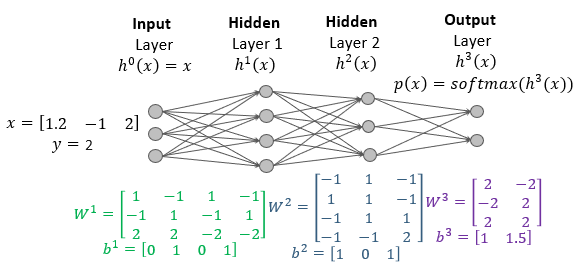

<span style="color:red">**(a)**</span>  What is the numerical value of the latent presentation $h^1(x)$?
<div style="text-align: right"><span style="color:red">[1 point]</span></div>

<span style="color:red">**(b)**</span>  What is the numerical value of the latent presentation $h^2(x)$?
<div style="text-align: right"><span style="color:red">[1 point]</span></div>

<span style="color:red">**(c)**</span>  What is the numerical value of the logit $h^3(x)$?
<div style="text-align: right"><span style="color:red">[1 point]</span></div>


<span style="color:red">**(d)**</span>  What is the corresonding prediction probabilities $p(x)$?
<div style="text-align: right"><span style="color:red">[1 point]</span></div>

<span style="color:red">**(e)**</span>  What is the predicted label $\widehat{y}$? Is it a correct and an incorect prediction? Remind that $y=2$.
<div style="text-align: right"><span style="color:red">[1 point]</span></div>


<span style="color:red">**(f)**</span>  What is the cross-entropy loss caused by the feed-forward neural network at $(x,y)$? Remind that $y=2$.
<div style="text-align: right"><span style="color:red">[1 point]</span></div>

<span style="color:red">**(g)**</span>  Why is the cross-entropy loss caused by the feed-forward neural network at $(x,y)$ (i.e., $\text{CE}(1_y, p(x))$) always non-negative? When does this $\text{CE}(1_y, p(x))$ loss get the value $0$? Note that you need to answer this question for a general pair $(x,y)$ and a general feed-forward neural network with, for example $M=4$ classes?   
<div style="text-align: right"><span style="color:red">[1 point]</span></div>


*You must show both formulas and numerical results for earning full mark. Although it is optional, it is great if you show your PyTorch code for your computation.*

(a)
$$
\begin{align}
z^{(1)} &= x W^{(1)} + b^{(1)} \\
        &=
\begin{bmatrix}
1.2 & -1 & 2
\end{bmatrix}
\begin{bmatrix}
1 & -1 & 1 & -1 \\
-1 & 1 & -1 & 1 \\
2 &  2 & -2 & -2
\end{bmatrix}
+
\begin{bmatrix}
0 & 1 & 0 & 1
\end{bmatrix} \\
        &=
\begin{bmatrix}
6.2 & 1.8 & -1.8 & -6.2
\end{bmatrix}
+
\begin{bmatrix}
0 & 1 & 0 & 1
\end{bmatrix} \\
        &=
\begin{bmatrix}
6.2 & 2.8 & -1.8 & -5.2
\end{bmatrix} \\
h^{(1)}(x) &= \max(0, z^{(1)}) =
\begin{bmatrix}
6.2 & 2.8 & 0 & 0
\end{bmatrix}
\end{align}
$$

In [1]:
import torch

# Input x
x = torch.tensor([1.2, -1.0, 2.0], dtype=torch.float64)

# Weights W1 and bias b1
W1 = torch.tensor([
    [1.0, -1.0, 1.0, -1.0],
    [-1.0, 1.0, -1.0, 1.0],
    [2.0, 2.0, -2.0, -2.0]
], dtype=torch.float64)

b1 = torch.tensor([0.0, 1.0, 0.0, 1.0], dtype=torch.float64)

z1 = torch.matmul(x, W1) + b1

h1 = torch.relu(z1)

print("h1 =", h1.tolist())

h1 = [6.2, 2.8, 0.0, 0.0]


(b)
$$
\begin{align}
z^{(2)} &= h^{(1)}(x) W^{(2)} + b^{(2)} \\
        &=
\begin{bmatrix}
6.2 & 2.8 & 0 & 0
\end{bmatrix}
\begin{bmatrix}
-1 & 1 & -1 \\
1 & 1 & -1  \\
-1 & 1 & 1 \\
-1 & -1 & 2
\end{bmatrix}
+
\begin{bmatrix}
1 & 0 & 1
\end{bmatrix} \\
        &=
\begin{bmatrix}
-3.4 & 9 & -9
\end{bmatrix}
+
\begin{bmatrix}
1 & 0 & 1
\end{bmatrix} \\
        &=
\begin{bmatrix}
-2.4 & 9 & -8
\end{bmatrix} \\
h^{(2)}(x) &= \max(0, z^{(2)}) =
\begin{bmatrix}
0 & 9 & 0
\end{bmatrix}
\end{align}
$$

In [2]:
W2 = torch.tensor([
    [-1.0, 1.0, -1.0],
    [1.0, 1.0, -1.0],
    [-1.0, 1.0, 1.0],
    [-1.0, -1.0, 2.0],
], dtype=torch.float64)

b2 = torch.tensor([1.0, 0.0, 1.0], dtype=torch.float64)

z2 = torch.matmul(h1, W2) + b2

h2 = torch.relu(z2)

print("h2 =", h2.tolist())

h2 = [0.0, 9.0, 0.0]


(c)
$$
\begin{align}
z^{(3)} &= h^{(2)}(x) W^{(3)} + b^{(3)} \\
        &=
\begin{bmatrix}
0 & 9 & 0
\end{bmatrix}
\begin{bmatrix}
2 & -2  \\
-2 & 2   \\
2 & 2  \\
\end{bmatrix}
+
\begin{bmatrix}
1 & 1.5
\end{bmatrix} \\
        &=
\begin{bmatrix}
-18 & 18
\end{bmatrix}
+
\begin{bmatrix}
1 & 1.5
\end{bmatrix} \\
        &=
\begin{bmatrix}
-17 & 19.5
\end{bmatrix} \\
\end{align}
$$

In [3]:
W3 = torch.tensor([
    [2.0, -2.0],
    [-2.0, 2.0],
    [2.0, 2.0],
], dtype=torch.float64)

b3 = torch.tensor([1.0, 1.5], dtype=torch.float64)

h3 = torch.matmul(h2, W3) + b3

print("h3 =", h3.tolist())

h3 = [-17.0, 19.5]


(d)
$$
\begin{aligned}
p(x) &= \mathrm{softmax}\big(h^{(3)}(x)\big) \\[6pt]
p_k(x) &= \frac{\exp\big(h_k^{(L)}(x)\big)}
{\displaystyle\sum_{j=1}^{M}\exp\big(h_j^{(L)}(x)\big)}
\end{aligned}
$$

For the specific vector \( h^{(3)}(x)=\begin{bmatrix}-17 & 19.5\end{bmatrix} \) (with \(L=3\) and \(M=2\)):

$$
\begin{aligned}
p_1(x) &= \frac{e^{-17}}{e^{-17} + e^{19.5}} \\
p_2(x) &= \frac{e^{19.5}}{e^{-17} + e^{19.5}} \\
\end{aligned}
$$

So the softmax probability vector is approximately:

$$
[p_1(x)\;\; p_2(x)] \approx [0\;\;1].
$$


In [4]:
pred_probs = torch.nn.Softmax(dim=0)(h3)

print("predicted probabilities =", [round(p, 4) for p in pred_probs.tolist()])

predicted probabilities = [0.0, 1.0]


(e)

Given the ground-truth label $y=2$:

$$
\hat{y} = \arg\max_{1 \leq k \leq 2} \; p_k(x).
$$

Since class $2$ has the highest predicted probability,
$$
\hat{y} = 2.
$$

Therefore,
$$
y = \hat{y},
$$
which means the predicted label matches the ground truth.  
Hence, this is a **correct prediction**.


(f)

The cross-entropy loss for a single example with true label $y$ is defined as:

$$
CE(\mathbf{1}_y, p(x)) = - \sum_{k=1}^{M} \mathbf{1}\{y=k\} \log p_k(x) = - \log p_y(x),
$$

where $p_k(x)$ is the softmax probability for class $k$, and $\mathbf{1}\{y=k\}$ is the indicator function.

For $y = 2$ and $p(x) = \begin{bmatrix}0 & 1 \end{bmatrix}$:

$$
CE({1}_y, 2) = - \left[ 0 \cdot \log(0) + 1 \cdot \log(1) \right]
$$

$$
CE({1}_y, 2) = - \log(1)
$$

$$
CE({1}_y, 2) \approx 0
$$


In [8]:
import torch
import torch.nn as nn

y = 1  # zero-based index for class 2
criterion = nn.CrossEntropyLoss() # Instantiate the loss function
ce_loss = criterion(h3.unsqueeze(0), torch.tensor([y])) # Compute the loss
print(f"CE loss: {ce_loss.item():.2f}") # Call .item() on the loss tensor

CE loss: 0.00


(g)

The cross-entropy loss caused by the feed-forward neural network at $(x, y)$, i.e., $CE(\mathbf{1}_y, p(x))$, is always non-negative because it is defined as the negative logarithm of a probability, and the probability score is always a number in the range $[0, 1]$. The negative logarithm of any value between 0 and 1 is always greater than or equal to 0.  

The cross-entropy loss for a single example $(x, y)$ is defined as:

$$
CE(\mathbf{1}_y, p(x)) = - \sum_{k=1}^{M} \mathbf{1}\{y=k\} \log p_k(x) = - \log p_y(x),
$$

where $p_k(x)$ is the predicted probability of class $k$ and $\mathbf{1}\{y=k\}$ is 1 only for the true class $y$ and 0 otherwise.  

The softmax output satisfies $0 \le p_k(x) \le 1$ for all $k$. The logarithm of a number of this range of possible values is always non-positive, $\log(p_k(x)) \le 0$.  
The negative sign in the formula ensures that the cross-entropy loss will always be non-negative.

This  CE(1y,p(x)) loss get the value 0 when the predicted probability for the true class is 1, i.e., $p_y(x) = 1$.

In that case:
$$
CE(\mathbf{1}_y, p(x)) = -log(1) = 0
$$

It means the neural network is completely confident and correct about the true class (perfect certainty).

####  <span style="color:red">**Question 1.3:**</span>
For **Question 1.3**, you have two options:
* **(1)** *perform the forward, backward propagation, and SGD update for `one mini-batch`* (**10 points**), or
* **(2)** *manually implement a feed-forward neural network* that can work on real tabular datasets (**20 points**).

You can choose either **(1)** or **(2)** to proceed.   

### <span style="color:red">**Option 2**</span>
<div style="text-align: right"><span style="color:red; font-weight:bold">[Total marks for this option: 20 points]<span></div>

In [2]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

**In Option 2, you need to implement a feed-forward NN manually using PyTorch and auto-differentiation of PyTorch. We then manually train the model on the MNIST dataset**.

We first download the `MNIST` dataset and preprocess it.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert the image to a tensor with shape [C, H, W]
    transforms.Normalize((0.5,), (0.5,)),  # Normalize to [-1, 1]
    transforms.Lambda(lambda x: x.view(28*28)) # Flatten the tensor to shape [-1,HW]
])

# Load the MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_data, train_labels = train_dataset.data, train_dataset.targets
test_data, test_labels = test_dataset.data, test_dataset.targets
print(train_data.shape, train_labels.shape)  # [# training images, height, width] and one label per image
print(test_data.shape, test_labels.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.96MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.58MB/s]

torch.Size([60000, 28, 28]) torch.Size([60000])
torch.Size([10000, 28, 28]) torch.Size([10000])


Each data point has dimension `[28,28]`. We need to flatten it to a vector to input to our FFN.

In [ ]:
train_dataset.data = train_data.data.reshape(-1, 28*28)
test_dataset.data = test_data.data.reshape(-1, 28*28)

train_data, train_labels = train_dataset.data, train_dataset.targets
test_data, test_labels = test_dataset.data, test_dataset.targets
print(train_data.shape, train_labels.shape)
print(test_data.shape, test_labels.shape)

torch.Size([60000, 784]) torch.Size([60000])
torch.Size([10000, 784]) torch.Size([10000])


We split the train and test sets into many mini-batches of 64.

In [ ]:
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

**Develop the feed-forward neural networks**

**(a)** You need to develop the class `MyLinear` with the following skeleton. You need to declare the weight matrix and bias of this linear layer.

<div style="text-align: right"><span style="color:red">[3 points]</span></div>

In [ ]:
from torch import nn
import torch.nn.functional as F

class MyLinear(torch.nn.Module):
  def __init__(self, input_size, output_size):
    """
    input_size: the size of the input
    output_size: the size of the output
    """
    super().__init__()
    #Your code here, weight and bias

    # create a matrix of random values * 0.01 so W start very small - prevent giant outputs
    # shape: [outputsize, inputsize]
    self.W = nn.Parameter(torch.randn(output_size, input_size) * 0.01)

    # starts at 0 so output depends purely on weighted inputs
    # shape: [outputsize,] one b per output neuron
    self.b = nn.Parameter(torch.zeros(output_size))

  #forward propagation
  def forward(self, x): #x is a mini-batch
    #Your code here
    return torch.matmul(x, self.W.T) + self.b

**(b)** You need to develop the class `MyFFN` with the following skeleton

<div style="text-align: right"><span style="color:red">[7 points]</span></div>

In [ ]:
class MyFFN(torch.nn.Module):
  def __init__(self, input_size, num_classes, hidden_sizes, act=torch.nn.ReLU()):
    """
    input_size: the size of the input
    num_classes: the number of classes
    act is the activation function
    hidden_sizes is the list of hidden sizes
    for example input_size = 3, hidden_sizes = [5, 7], num_classes = 4, and act = torch.nn.ReLU()
    means that we are building up a FFN with the confirguration
    (3 (Input) -> 5 (ReLU) -> 7 (ReLU) -> 4 (Output))
    """
    super(MyFFN, self).__init__()
    self.input_size = input_size
    self.num_classes = num_classes
    self.act = act
    self.hidden_sizes = hidden_sizes
    self.num_layers = len(hidden_sizes) + 1


  def create_FFN(self):
    """
    This function creates the feed-forward neural network
    We stack many MyLinear layers
    """
    hidden_sizes = [self.input_size] + self.hidden_sizes + [self.num_classes]
    self.layers = []
    #Your code here
    for i in range(self.num_layers):
      self.layers.append(MyLinear(hidden_sizes[i], hidden_sizes[i+1]))
    self.layers = nn.ModuleList(self.layers)


  def forward(self,x):
    """
    This implements the forward propagation of the batch x
    This needs to return the logits of x
    """
    #Your code here
    for i, layer in enumerate(self.layers):
        x = layer(x)

        # apply activation except last layer
        if i < len(self.layers) - 1:
            x = self.act(x)
    return x

  def compute_loss(self, x, y):
    """
    This function computes the cross-entropy loss
    You can use the built-in CE loss of PyTorch
    """
    #Your code here
    logits = self.forward(x)
    ce_loss= nn.functional.cross_entropy(logits, y)
    return ce_loss

  def update_SGD(self, x, y, learning_rate = 0.01):
    """
    This function updates the model parameters using SGD using the batch (x,y)
    You need to implement the update rule manually and cannot rely on the built-in optimizer
    """
    #Your code here
    # forward pass then compute loss
    self.train()
    loss = self.compute_loss(x, y)

    # zero gradient
    self.zero_grad()

    # backward pass: adjust w and b to minimize the error
    loss.backward()

    # parameter update
    with torch.no_grad():
      for param in self.parameters():
        param -= learning_rate * param.grad

    # convert 0-dim tensor to python float
    return loss.item()

  def update_SGDwithMomentum(self, x, y, learning_rate = 0.01, momentum = 0.9):
    """
    This function updates the model parameters using SGD with momentum using the batch (x,y)
    You need to implement the update rule manually and cannot rely on the built-in optimizer
    """
    #Your code here
    self.train()

    # Initialize velocity dict on first call
    if not hasattr(self, "velocity"):
        self.velocity = {param: torch.zeros_like(param) for param in self.parameters()}

    # forward pass then compute loss
    loss = self.compute_loss(x, y)

    # zero gradient
    self.zero_grad()

    # backward pass: adjust w and b to minimize the error
    loss.backward()

    # parameter update
    with torch.no_grad():
      for param in self.parameters():
        if param.grad is None:
            continue  # skip if no grad

        # Update velocity: combine old velocity & current gradient
        self.velocity[param] = momentum * self.velocity[param] - learning_rate * param.grad

        # Update parameter
        param += self.velocity[param]

    # convert 0-dim tensor to python float
    return loss.item()

  def update_AdaGrad(self, x, y, learning_rate = 0.01):
    """
    This function updates the model parameters using AdaGrad using the batch (x,y)
    You need to implement the update rule manually and cannot rely on the built-in optimizer
    """
    #Your code here
    self.train()
    epsilon = 1e-6
    if not hasattr(self, "ada_grad"):
        self.ada_grad = {param: torch.zeros_like(param) for param in self.parameters()}

    # forward pass then compute loss
    loss = self.compute_loss(x, y)

    # zero gradient
    self.zero_grad()

    # backward pass: adjust w and b to minimize the error
    loss.backward()

    # parameter update
    with torch.no_grad():
      for param in self.parameters():
        if param.grad is None:
            continue  # skip if no grad

        # accumulate squared gradients
        self.ada_grad[param] += param.grad ** 2

        param -= (learning_rate / torch.sqrt(self.ada_grad[param] + epsilon)) * param.grad

    # convert 0-dim tensor to python float
    return loss.item()

In [ ]:
myFFN = MyFFN(input_size = 28*28, num_classes = 10, hidden_sizes = [100, 100], act = torch.nn.ReLU()) # Instantiate ReLU
myFFN.create_FFN()
print(myFFN)

MyFFN(
  (act): ReLU()
  (layers): ModuleList(
    (0-2): 3 x MyLinear()
  )
)


**(c)** Write the code to evaluate the accuracy of the current `myFFN` model on a data loader (e.g., train_loader or test_loader).

<div style="text-align: right"><span style="color:red">[2.5 points]</span></div>

In [ ]:
def compute_acc(model, data_loader):
  """
  This function computes the accuracy of the model on a data loader
  """
  #Your code here
  device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

  corrects = 0
  totals =0

  model.eval()
  # In test phase, we don't need to compute gradients (for memory efficiency)
  with torch.no_grad():
    for (batchX, batchY) in data_loader:
      batchX, batchY = batchX.to(device), batchY.to(device)

      # feed the input batch to the model and get prediction.
      # output: logits/raw scores
      outputs = model(batchX.type(torch.float32)) #feed batch to the model

      # increase the total count by the number of samples in current batch
      totals += batchY.size(0)

      # get the predicted class
      predicted = torch.argmax(outputs, 1)

      # accumulate correct predictions
      # compare prediction with true labels
      # .item() convert from tensors to Python scalar.
      corrects += (predicted == batchY.type(torch.long)).sum().item()

  acc = float(corrects)/totals #compute the accuracy
  return acc

(d) Write the code to evaluate the loss of the current myFFN model on a data loader (e.g., train_loader or test_loader).

In [ ]:
def compute_loss(model, data_loader):
  """
  This function computes the loss of the model on a data loader
  """
  #Your code here
  model.eval()
  device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  total_loss = 0.0

  with torch.no_grad():  # no gradient tracking needed
      for (batchX, batchY) in data_loader:
          batchX, batchY = batchX.to(device), batchY.to(device)

          # use model's compute_loss if available
          batch_loss = model.compute_loss(batchX.type(torch.float32), batchY.type(torch.long))
          total_loss += batch_loss.item()

  return total_loss / len(data_loader)

Train on the `MNIST` data with 50 epochs using `updateSGD`.

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

myFFN = myFFN.to(device)

num_epochs = 50
for epoch in range(num_epochs):
    for i, (x, y) in enumerate(train_loader):
      x, y = x.to(device), y.to(device)
      myFFN.update_SGD(x.type(torch.float32), y.type(torch.long), learning_rate = 0.01)
    train_acc = compute_acc(myFFN, train_loader)
    train_loss = compute_loss(myFFN, train_loader)
    test_acc = compute_acc(myFFN, test_loader)
    test_loss = compute_loss(myFFN, test_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%, Test Loss: {test_loss:.4f}, Test Acc: {test_acc*100:.2f}%")

Epoch 1/50, Train Loss: 0.3585, Train Acc: 89.84%, Test Loss: 0.3499, Test Acc: 89.85%
Epoch 2/50, Train Loss: 0.3176, Train Acc: 90.72%, Test Loss: 0.3143, Test Acc: 90.84%
Epoch 3/50, Train Loss: 0.2883, Train Acc: 91.77%, Test Loss: 0.2843, Test Acc: 91.66%
Epoch 4/50, Train Loss: 0.2687, Train Acc: 92.16%, Test Loss: 0.2672, Test Acc: 92.22%
Epoch 5/50, Train Loss: 0.2456, Train Acc: 92.94%, Test Loss: 0.2484, Test Acc: 92.69%
Epoch 6/50, Train Loss: 0.2266, Train Acc: 93.38%, Test Loss: 0.2279, Test Acc: 93.23%
Epoch 7/50, Train Loss: 0.2082, Train Acc: 93.87%, Test Loss: 0.2099, Test Acc: 93.65%
Epoch 8/50, Train Loss: 0.1934, Train Acc: 94.34%, Test Loss: 0.1989, Test Acc: 94.10%
Epoch 9/50, Train Loss: 0.1776, Train Acc: 94.88%, Test Loss: 0.1848, Test Acc: 94.56%
Epoch 10/50, Train Loss: 0.1685, Train Acc: 95.04%, Test Loss: 0.1767, Test Acc: 94.91%
Epoch 11/50, Train Loss: 0.1822, Train Acc: 94.32%, Test Loss: 0.1951, Test Acc: 93.89%
Epoch 12/50, Train Loss: 0.1635, Train Ac

In [ ]:
myFFN.eval()   # evaluation mode

with torch.no_grad():  # no gradients needed
    test_acc = compute_acc(myFFN, test_loader)
    test_loss = compute_loss(myFFN, test_loader)

print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 97.40%
Test Loss: 0.0849


**(e)** Implement the function `updateSGDMomentum` in the class and train the model with this optimizer in `50` epochs. You can update the corresponding function in the `MyFNN` class.

<div style="text-align: right"><span style="color:red">[2.5 points]</span></div>

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

myFFN = myFFN.to(device)

num_epochs = 50
for epoch in range(num_epochs):
    for i, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)
        myFFN.update_SGDwithMomentum(x.type(torch.float32), y.type(torch.long), learning_rate=0.01, momentum=0.9)

    train_acc = compute_acc(myFFN, train_loader)
    train_loss = compute_loss(myFFN, train_loader)
    test_acc = compute_acc(myFFN, test_loader)
    test_loss = compute_loss(myFFN, test_loader)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, "
          f"Train Acc: {train_acc*100:.2f}%, Test Loss: {test_loss:.4f}, Test Acc: {test_acc*100:.2f}%")

Epoch 1/50, Train Loss: 0.1087, Train Acc: 96.45%, Test Loss: 0.1402, Test Acc: 95.53%
Epoch 2/50, Train Loss: 0.0727, Train Acc: 97.65%, Test Loss: 0.1045, Test Acc: 96.79%
Epoch 3/50, Train Loss: 0.0578, Train Acc: 98.14%, Test Loss: 0.0916, Test Acc: 97.19%
Epoch 4/50, Train Loss: 0.0573, Train Acc: 98.17%, Test Loss: 0.0948, Test Acc: 97.11%
Epoch 5/50, Train Loss: 0.0461, Train Acc: 98.51%, Test Loss: 0.0883, Test Acc: 97.28%
Epoch 6/50, Train Loss: 0.0485, Train Acc: 98.37%, Test Loss: 0.0948, Test Acc: 97.15%
Epoch 7/50, Train Loss: 0.0523, Train Acc: 98.22%, Test Loss: 0.1033, Test Acc: 96.84%
Epoch 8/50, Train Loss: 0.0618, Train Acc: 97.98%, Test Loss: 0.1174, Test Acc: 96.76%
Epoch 9/50, Train Loss: 0.0339, Train Acc: 98.88%, Test Loss: 0.0805, Test Acc: 97.59%
Epoch 10/50, Train Loss: 0.0305, Train Acc: 98.98%, Test Loss: 0.0825, Test Acc: 97.42%
Epoch 11/50, Train Loss: 0.0275, Train Acc: 99.09%, Test Loss: 0.0888, Test Acc: 97.54%
Epoch 12/50, Train Loss: 0.0245, Train Ac

In [ ]:
myFFN.eval()   # evaluation mode

with torch.no_grad():  # no gradients needed
    test_acc = compute_acc(myFFN, test_loader)
    test_loss = compute_loss(myFFN, test_loader)

print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 98.19%
Test Loss: 0.0995


**(f)** Implement the function `updateAdagrad` in the class and train the model with this optimizer in `50` epochs. You can update the corresponding function in the `MyFNN` class.

<div style="text-align: right"><span style="color:red">[2.5 points]</span></div>

In [ ]:
#Your code here
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

myFFN = myFFN.to(device)

num_epochs = 50
for epoch in range(num_epochs):
    for i, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)
        myFFN.update_AdaGrad(x.type(torch.float32), y.type(torch.long), learning_rate=0.01)

    train_acc = compute_acc(myFFN, train_loader)
    train_loss = compute_loss(myFFN, train_loader)
    test_acc = compute_acc(myFFN, test_loader)
    test_loss = compute_loss(myFFN, test_loader)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, "
          f"Train Acc: {train_acc*100:.2f}%, Test Loss: {test_loss:.4f}, Test Acc: {test_acc*100:.2f}%")

Epoch 1/50, Train Loss: 0.0031, Train Acc: 99.92%, Test Loss: 0.0985, Test Acc: 97.98%
Epoch 2/50, Train Loss: 0.0013, Train Acc: 99.99%, Test Loss: 0.1017, Test Acc: 98.03%
Epoch 3/50, Train Loss: 0.0007, Train Acc: 100.00%, Test Loss: 0.1009, Test Acc: 98.08%
Epoch 4/50, Train Loss: 0.0006, Train Acc: 100.00%, Test Loss: 0.1004, Test Acc: 98.06%
Epoch 5/50, Train Loss: 0.0005, Train Acc: 100.00%, Test Loss: 0.0993, Test Acc: 98.09%
Epoch 6/50, Train Loss: 0.0004, Train Acc: 100.00%, Test Loss: 0.0996, Test Acc: 98.14%
Epoch 7/50, Train Loss: 0.0004, Train Acc: 100.00%, Test Loss: 0.0999, Test Acc: 98.16%
Epoch 8/50, Train Loss: 0.0004, Train Acc: 100.00%, Test Loss: 0.1006, Test Acc: 98.15%
Epoch 9/50, Train Loss: 0.0003, Train Acc: 100.00%, Test Loss: 0.1010, Test Acc: 98.16%
Epoch 10/50, Train Loss: 0.0003, Train Acc: 100.00%, Test Loss: 0.1012, Test Acc: 98.17%
Epoch 11/50, Train Loss: 0.0003, Train Acc: 100.00%, Test Loss: 0.1015, Test Acc: 98.13%
Epoch 12/50, Train Loss: 0.0003,

In [ ]:
myFFN.eval()

with torch.no_grad():  # no gradients needed
    test_acc = compute_acc(myFFN, test_loader)
    test_loss = compute_loss(myFFN, test_loader)

print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 98.17%
Test Loss: 0.1073


---
### <span style="color:#0b486b"> <div  style="text-align:center">**THE END**</div> </span>